In [1]:
import sys
sys.path.insert(0, "/rds/rds-clecat/pipeline_alina_full/alina_paper/scattering_transform")

In [5]:
from wst_sv_1 import compute_wst_S012
i =0
res = compute_wst_S012(
    f"/rds/maps_sbi_10by10patch_final/map_sbi_10t10patch_1.4beam_1024_{i}.fits",   # dossier parent contenant des sous-dossiers
    J=5, L=5,
    device="auto",
    whiten=False,
    samples_format='long', #pour avoir tous les coefs
    plot=True,
    which="S1",
    save_samples_csv="/rds/rds-clecat/pipeline_alina_full/alina_paper/pipeline_outputs/paints_100_test_wst/", 
    save_plot="/rds/rds-clecat/pipeline_alina_full/alina_paper/pipeline_outputs/paints_100_wst_plot/", 
    quiet=False
)

[export] samples -> /rds/rds-clecat/pipeline_alina_full/alina_paper/pipeline_outputs/paints_100_test_wst/samples.csv (format=long, kinds=S1,S0)


In [ ]:
# run_wst_mpi.py
# Usage:
#   mpirun -np 32 python run_wst_mpi.py --start 0 --end 9999
# Optional flags let you tweak J/L/which/paths without editing code.

import os
import argparse
from mpi4py import MPI

# If compute_wst_S012 lives in a module, import it here, e.g.:
# from yourmodule import compute_wst_S012

def parse_args():
    p = argparse.ArgumentParser(description="MPI runner for compute_wst_S012 over many FITS maps.")
    p.add_argument("--start", type=int, default=0, help="Start index (inclusive).")
    p.add_argument("--end", type=int, default=9999, help="End index (inclusive).")
    p.add_argument("--pattern", type=str,
                   default="/rds/maps_sbi_10by10patch_final/map_sbi_10t10patch_1.4beam_1024_{i}.fits",
                   help="Input path pattern with {i} placeholder.")
    p.add_argument("--J", type=int, default=5)
    p.add_argument("--L", type=int, default=5)
    p.add_argument("--which", type=str, default="S1", choices=["S0","S1","S2","S01","S012","S12"])
    p.add_argument("--save_samples_csv", type=str,
                   default="/rds/rds-clecat/pipeline_alina_full/alina_paper/pipeline_outputs/paints_100_test_wst/")
    p.add_argument("--save_plot", type=str,
                   default="/rds/rds-clecat/pipeline_alina_full/alina_paper/pipeline_outputs/paints_100_wst_plot/")
    p.add_argument("--whiten", action="store_true", help="Enable whitening (default: False).")
    p.add_argument("--no-plot", action="store_true", help="Disable plotting.")
    p.add_argument("--quiet", action="store_true", help="Reduce verbosity from compute_wst_S012.")
    p.add_argument("--retries", type=int, default=2, help="Retries per file on failure.")
    return p.parse_args()

def ensure_dirs(*paths):
    for p in paths:
        if p:
            os.makedirs(p, exist_ok=True)

def process_index(i, args):
    path = args.pattern.format(i=i)
    if not os.path.exists(path):
        return f"MISS {i}: {path} (not found)"

    # Optional: quick skip if you have an obvious per-index artifact to detect.
    # (Leaving generic since compute_wst_S012 controls filenames.)
    attempt = 0
    last_err = None
    while attempt <= args.retries:
        try:
            res = compute_wst_S012(
                path,
                J=args.J, L=args.L,
                device="auto",
                whiten=args.whiten,
                samples_format="long",
                plot=(not args.no-plot),
                which=args.which,
                save_samples_csv=args.save_samples_csv,
                save_plot=args.save_plot,
                quiet=args.quiet is True
            )
            return f"DONE {i}"
        except Exception as e:
            last_err = e
            attempt += 1
    return f"FAIL {i}: {type(last_err).__name__}: {last_err}"

def main():
    args = parse_args()

    # MPI init
    comm = MPI.COMM_WORLD
    rank = comm.Get_rank()
    size = comm.Get_size()

    if rank == 0:
        ensure_dirs(args.save_samples_csv, args.save_plot)

    # Simple barrier to ensure dirs exist before workers write
    comm.Barrier()

    # Distribute work by striding over indices
    indices = range(args.start, args.end + 1)
    my_indices = [i for j, i in enumerate(indices) if j % size == rank]

    # Process
    results = []
    for i in my_indices:
        msg = process_index(i, args)
        results.append(msg)
        # Lightweight per-item feedback from each rank (optional)
        print(f"[rank {rank}/{size}] {msg}", flush=True)

    # Gather a brief summary on rank 0
    all_results = comm.gather(results, root=0)
    if rank == 0:
        done = sum(m.startswith("DONE") for r in all_results for m in r)
        miss = sum(m.startswith("MISS") for r in all_results for m in r)
        fail = sum(m.startswith("FAIL") for r in all_results for m in r)
        print(f"\nSummary: DONE={done}  MISS={miss}  FAIL={fail}")

if __name__ == "__main__":
    main()


In [ ]:
import os
import argparse
from mpi4py import MPI

In [1]:
#plot everything

In [3]:
import pandas as pd

csv_path = "/rds/rds-clecat/pipeline_alina_full/alina_paper/wst_outputs/wst_full_coefs/samples_rank0_part00000.csv"   # your combined file
df = pd.read_csv(csv_path, comment="#")  # skips the metadata header line

# sanity
assert set(["sample","kind","index","value"]).issubset(df.columns)
df.head()


,sample,kind,index,value
0,0,S0,0,1.997079e-07
1,1,S0,0,1.031963e-07
2,2,S0,0,2.044099e-08
3,3,S0,0,9.218274e-07
4,4,S0,0,6.351996e-07


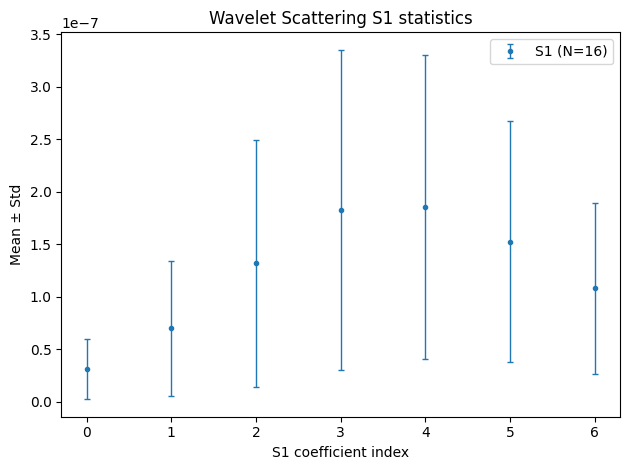

In [5]:
import numpy as np
import matplotlib.pyplot as plt

s1 = df[df["kind"]=="S1"]
# aggregate over all samples for each coefficient index
g = s1.groupby("index")["value"]
s1_mean = g.mean()
s1_std  = g.std(ddof=1)

x = s1_mean.index.to_numpy()
y = s1_mean.to_numpy()
yerr = s1_std.to_numpy()

plt.figure()
plt.errorbar(x, y, yerr=yerr, fmt='o', ms=3, lw=1, capsize=2, label=f"S1 (N={s1['sample'].nunique()})")
plt.xlabel("S1 coefficient index")
plt.ylabel("Mean ± Std")
plt.title("Wavelet Scattering S1 statistics")
plt.legend()
plt.tight_layout()
plt.show()


[INFO] Fichier chargé : 128 lignes, colonnes = ['sample', 'kind', 'index', 'value']
[INFO] Nombre de patchs (cosmologies) : 16


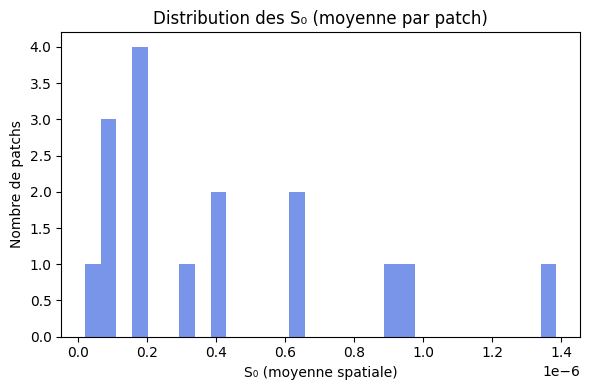

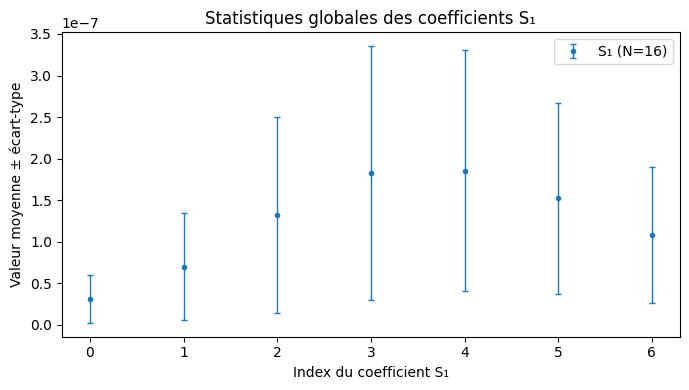

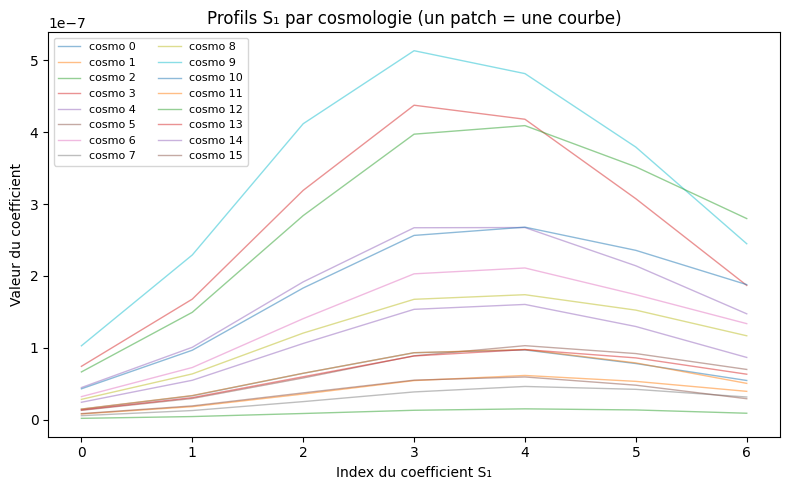

[INFO] Aucun coefficient S₂ trouvé dans le fichier.

[OK] Graphiques terminés.


In [8]:
#!/usr/bin/env python3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ==============================
# CONFIGURATION
# ==============================
CSV_PATH = "/rds/rds-clecat/pipeline_alina_full/alina_paper/wst_outputs/wst_full_coefs/samples_rank0_part00000.csv"   # <-- mets ici ton fichier

# ==============================
# LECTURE DU FICHIER
# ==============================
if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"Fichier introuvable : {CSV_PATH}")

# Lecture en ignorant la ligne de métadonnées (commençant par '#')
df = pd.read_csv(CSV_PATH, comment="#")

print(f"[INFO] Fichier chargé : {len(df)} lignes, colonnes = {list(df.columns)}")
print(f"[INFO] Nombre de patchs (cosmologies) : {df['sample'].nunique()}")

# ==============================
# HISTOGRAMME DES S0
# ==============================
s0 = df[df["kind"] == "S0"]["value"].to_numpy()

plt.figure(figsize=(6,4))
plt.hist(s0, bins=30, color="royalblue", alpha=0.7)
plt.xlabel("S₀ (moyenne spatiale)")
plt.ylabel("Nombre de patchs")
plt.title("Distribution des S₀ (moyenne par patch)")
plt.tight_layout()
plt.show()

# ==============================
# MOYENNE ET ÉCART-TYPE DES S1 (SUR TOUS LES PATCHS)
# ==============================
s1 = df[df["kind"] == "S1"]

g = s1.groupby("index")["value"]
s1_mean = g.mean()
s1_std  = g.std(ddof=1)

x = s1_mean.index.to_numpy()
y = s1_mean.to_numpy()
yerr = s1_std.to_numpy()

plt.figure(figsize=(7,4))
plt.errorbar(x, y, yerr=yerr, fmt='o', ms=3, lw=1, capsize=2, label=f"S₁ (N={s1['sample'].nunique()})")
plt.xlabel("Index du coefficient S₁")
plt.ylabel("Valeur moyenne ± écart-type")
plt.title("Statistiques globales des coefficients S₁")
plt.legend()
plt.tight_layout()
plt.show()

# ==============================
# COURBES S1 PAR COSMOLOGIE
# ==============================
# Chaque patch correspond à une cosmologie différente
pivot = s1.pivot(index="index", columns="sample", values="value")

plt.figure(figsize=(8,5))
for col in pivot.columns:
    plt.plot(pivot.index, pivot[col], alpha=0.5, lw=1, label=f"cosmo {col}")
plt.xlabel("Index du coefficient S₁")
plt.ylabel("Valeur du coefficient")
plt.title("Profils S₁ par cosmologie (un patch = une courbe)")
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

# ==============================
# (OPTIONNEL) S2 SI PRÉSENT
# ==============================
if "S2" in df["kind"].unique():
    s2 = df[df["kind"] == "S2"]
    g2 = s2.groupby("index")["value"]
    s2_mean = g2.mean()
    s2_std = g2.std(ddof=1)
    
    plt.figure(figsize=(7,4))
    plt.errorbar(
        s2_mean.index, s2_mean, yerr=s2_std,
        fmt='o', ms=3, lw=1, capsize=2, label="S₂"
    )
    plt.xlabel("Index du coefficient S₂")
    plt.ylabel("Valeur moyenne ± écart-type")
    plt.title("Statistiques globales des coefficients S₂")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("[INFO] Aucun coefficient S₂ trouvé dans le fichier.")

print("\n[OK] Graphiques terminés.")


[INFO] colonnes : ['sample', 'kind', 'index', 'value']
[INFO] samples disponibles : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15)]
[INFO] S0 pour sample=3 : 9.218274499289693e-07


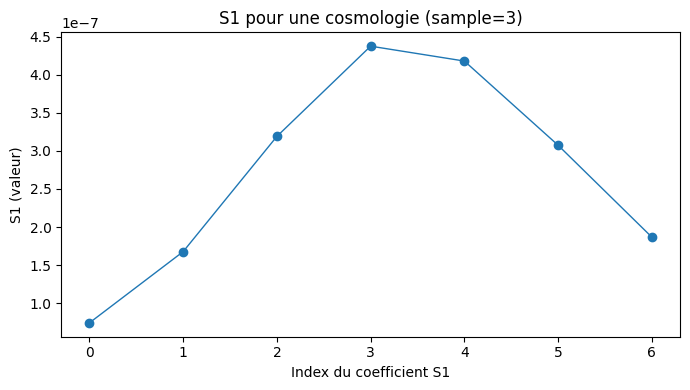

[INFO] pas de S2 dans ce fichier pour sample=3.


In [10]:
#!/usr/bin/env python3
import os
import pandas as pd
import matplotlib.pyplot as plt

# ==========
# PARAMS
# ==========
CSV_PATH   = "/rds/rds-clecat/pipeline_alina_full/alina_paper/wst_outputs/wst_full_coefs/samples_rank0_part00000.csv"  # ou samples_all.csv
SAMPLE_ID  = 3   # <- le patch/cosmologie que tu veux tracer (0..15 pour un CSV de batch)

# ==========
# LECTURE
# ==========
if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(CSV_PATH)

df = pd.read_csv(CSV_PATH, comment="#")  # ignore la 1ère ligne "# n_samples=..."

# Petit coup d’œil
print("[INFO] colonnes :", list(df.columns))
print("[INFO] samples disponibles :", sorted(df["sample"].unique()))

# ==========
# S0 DU PATCH
# ==========
s0_patch = df[(df["kind"]=="S0") & (df["sample"]==SAMPLE_ID)]["value"].to_numpy()
if s0_patch.size:
    print(f"[INFO] S0 pour sample={SAMPLE_ID} :", s0_patch[0])
else:
    print(f"[WARN] pas de S0 pour sample={SAMPLE_ID} dans ce fichier.")

# ==========
# S1 DU PATCH
# ==========
s1_patch = df[(df["kind"]=="S1") & (df["sample"]==SAMPLE_ID)].sort_values("index")
if s1_patch.empty:
    raise RuntimeError(f"Aucun S1 pour sample={SAMPLE_ID} dans {CSV_PATH}")

plt.figure(figsize=(7,4))
plt.plot(s1_patch["index"].to_numpy(), s1_patch["value"].to_numpy(), marker="o", lw=1)
plt.xlabel("Index du coefficient S1")
plt.ylabel("S1 (valeur)")
plt.title(f"S1 pour une cosmologie (sample={SAMPLE_ID})")
plt.tight_layout()
plt.show()

# ==========
# (OPTIONNEL) S2 DU PATCH
# ==========
s2_patch = df[(df["kind"]=="S2") & (df["sample"]==SAMPLE_ID)].sort_values("index")
if not s2_patch.empty:
    plt.figure(figsize=(7,4))
    plt.plot(s2_patch["index"].to_numpy(), s2_patch["value"].to_numpy(), marker="o", lw=1)
    plt.xlabel("Index du coefficient S2")
    plt.ylabel("S2 (valeur)")
    plt.title(f"S2 pour une cosmologie (sample={SAMPLE_ID})")
    plt.tight_layout()
    plt.show()
else:
    print(f"[INFO] pas de S2 dans ce fichier pour sample={SAMPLE_ID}.")


In [6]:
import pandas as pd
import numpy as np

csv_path = "/rds/rds-clecat/pipeline_alina_full/alina_paper/wst_outputs/wst_full_coefs/wst_map_0.csv"

# Load CSV, skipping commented header
df = pd.read_csv(csv_path, comment="#")

print("Columns:", df.columns.tolist())
print("\nHead:\n", df.head())

# ---- Case 1: wide format (S0*, S1*, S2* as columns) ----
s0_cols = [c for c in df.columns if c.startswith("S0")]
s1_cols = [c for c in df.columns if c.startswith("S1")]
s2_cols = [c for c in df.columns if c.startswith("S2")]

if s0_cols or s1_cols or s2_cols:
    print("\nDetected WIDE format")

    n_s0 = df[s0_cols].notna().sum().sum() if s0_cols else 0
    n_s1 = df[s1_cols].notna().sum().sum() if s1_cols else 0
    n_s2 = df[s2_cols].notna().sum().sum() if s2_cols else 0

    print(f"S0 non-NaN entries: {n_s0}")
    print(f"S1 non-NaN entries: {n_s1}")
    print(f"S2 non-NaN entries: {n_s2}")

else:
    # ---- Case 2: long format (rows with kind='S0'/'S1'/'S2') ----
    print("\nNo S0*/S1*/S2* columns found, trying LONG format")

    # Try to guess the "kind" column
    candidate_kind_cols = [c for c in df.columns if df[c].dtype == object]
    kind_col = None
    for c in candidate_kind_cols:
        vals = set(df[c].astype(str).unique())
        if any(v.startswith("S0") for v in vals) or \
           any(v.startswith("S1") for v in vals) or \
           any(v.startswith("S2") for v in vals):
            kind_col = c
            break

    if kind_col is None:
        raise RuntimeError(
            "Could not find a column that encodes S0/S1/S2 kinds. "
            "Check the printed columns and head above."
        )

    print(f"Using '{kind_col}' as kind column")

    # Numeric columns (likely the coefficient values)
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    # Common non-coefficient numeric cols to exclude
    for drop in ["sample", "map_label", "index"]:
        if drop in num_cols:
            num_cols.remove(drop)

    if not num_cols:
        raise RuntimeError("No numeric coefficient columns found.")

    # If there are several numeric columns, we count all of them
    def count_non_nan_for(kind):
        mask = df[kind_col].astype(str).str.startswith(kind)
        if not mask.any():
            return 0
        return df.loc[mask, num_cols].notna().sum().sum()

    n_s0 = count_non_nan_for("S0")
    n_s1 = count_non_nan_for("S1")
    n_s2 = count_non_nan_for("S2")

    # These are effectively the “dimensions” (number of stored coefficients)
    print(f"S0 non-NaN entries: {n_s0}")
    print(f"S1 non-NaN entries: {n_s1}")
    print(f"S2 non-NaN entries: {n_s2}")


Columns: ['sample', 'kind', 'index', 'value']

Head:
    sample kind  index         value
0       0   S0      0  1.997079e-07
1       0   S1      0  1.472724e-08
2       0   S1      1  3.334416e-08
3       0   S1      2  6.456231e-08
4       0   S1      3  9.320085e-08

No S0*/S1*/S2* columns found, trying LONG format
Using 'kind' as kind column
S0 non-NaN entries: 1
S1 non-NaN entries: 7
S2 non-NaN entries: 112
